In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

In [2]:
import plotly.io as pio
pio.renderers.default='browser'

In [43]:
import matplotlib.pyplot as plt

In [51]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

In [3]:
DATA = "data/"
DATA_FILE = "household_data_15min_singleindex.csv"
HOUSHOLD_TS = DATA + DATA_FILE

In [4]:
df_all_ts = pd.read_csv(HOUSHOLD_TS)

In [5]:
all_cols = df_all_ts.columns.tolist()

### 1. Categorize columns

In [6]:
pv_cols = [c for c in all_cols if "_pv" in c]

In [7]:
battery_cols = [
    c for c in all_cols
    if "storage_charge" in c or "storage_decharge" in c or "battery" in c
]

In [8]:
grid_cols = [
    c for c in all_cols
    if "grid_import" in c or "grid_export" in c
]

In [9]:
exclude = (
    pv_cols
    + battery_cols
    + grid_cols
    + ["utc_timestamp", "cet_cest_timestamp", "interpolated"]
)

In [10]:
load_cols = [c for c in all_cols if c not in exclude]

### 2. Create category tables

In [11]:
df_load = df_all_ts[["utc_timestamp"] + load_cols]
df_pv = df_all_ts[["utc_timestamp"] + pv_cols]
df_grid = df_all_ts[["utc_timestamp"] + grid_cols]
df_battery = df_all_ts[["utc_timestamp"] + battery_cols]

### 3. Synthesize compact energy table

In [12]:
energy_df = pd.DataFrame({
    "utc_timestamp": df_all_ts["utc_timestamp"],

    # total demand / consumption
    "load": df_all_ts[load_cols].sum(axis=1),

    # total PV generation
    "pv": df_all_ts[pv_cols].sum(axis=1),

    # net grid exchange
    # import positive, export negative
    "grid": (
        df_all_ts[[c for c in grid_cols if "import" in c]].sum(axis=1)
        - df_all_ts[[c for c in grid_cols if "export" in c]].sum(axis=1)
    ),

    # battery net power
    # charge negative, discharge positive
    "battery": (
        df_all_ts[[c for c in battery_cols if "decharge" in c]].sum(axis=1)
        - df_all_ts[[c for c in battery_cols if "charge" in c]].sum(axis=1)
    )
})

In [13]:
cols = ["load", "pv", "grid", "battery"]

In [14]:
energy_df.head()

,utc_timestamp,load,pv,grid,battery
0,2014-12-11T17:45:00Z,0.002,0.0,0.0,0.0
1,2014-12-11T18:00:00Z,0.036,0.0,0.0,0.0
2,2014-12-11T18:15:00Z,0.054,0.0,0.0,0.0
3,2014-12-11T18:30:00Z,0.072,0.0,0.0,0.0
4,2014-12-11T18:45:00Z,0.090,0.0,0.0,0.0


In [15]:
energy_df["utc_timestamp"] = pd.to_datetime(
    energy_df["utc_timestamp"],
    utc=True,
)

In [16]:
energy_df = energy_df.set_index("utc_timestamp")

In [17]:
power_df = energy_df.diff()

In [18]:
power_df.head()

,load,pv,grid,battery
utc_timestamp,,,,
2014-12-11 17:45:00+00:00,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,0.034,0.0,0.0,0.0
2014-12-11 18:15:00+00:00,0.018,0.0,0.0,0.0
2014-12-11 18:30:00+00:00,0.018,0.0,0.0,0.0
2014-12-11 18:45:00+00:00,0.018,0.0,0.0,0.0


In [19]:
# power_df = power_df.reset_index()

In [20]:
start = pd.Timestamp("2016-11-15 00:00:00", tz="UTC")
end   = start + pd.Timedelta(days=90)

In [21]:
'''
sample_df = power_df[
    (power_df["utc_timestamp"] >= start) &
    (power_df["utc_timestamp"] <= end)
]
'''

'\nsample_df = power_df[\n    (power_df["utc_timestamp"] >= start) &\n    (power_df["utc_timestamp"] <= end)\n]\n'

In [22]:
sample_df = power_df[start : end]

In [23]:
sample_df

,load,pv,grid,battery
utc_timestamp,,,,
2016-11-15 00:00:00+00:00,13.532,0.0,25.789,-0.005
2016-11-15 00:15:00+00:00,13.089,0.0,22.286,-0.005
2016-11-15 00:30:00+00:00,12.575,0.0,21.363,-0.005
2016-11-15 00:45:00+00:00,13.206,0.0,23.407,-0.005
2016-11-15 01:00:00+00:00,13.083,0.0,22.491,-0.005
...,...,...,...,...
2017-02-12 23:00:00+00:00,13.292,0.0,22.679,-0.005
2017-02-12 23:15:00+00:00,12.614,0.0,22.513,-0.005
2017-02-12 23:30:00+00:00,13.362,0.0,23.302,-0.005


In [24]:
from plot_utils import TelemertyPlotter

In [25]:
plotter = TelemertyPlotter(sample_df, primary_cols=cols, secondary_cols=[])

In [26]:
plotter.show()

### Clear Anomalies

In [27]:
power_df[["load", "pv"]] = power_df[["load", "pv"]].clip(lower=0)

### Prepare for Training Pipeline 

In [29]:
TARGET = "load"

In [30]:
power_df = power_df[[TARGET]]

In [31]:
power_df = power_df.copy()

power_df.index = pd.to_datetime(power_df.index, utc=True)

power_df = power_df.sort_index()

power_df = power_df.asfreq("15min")  # or your actual resolution

In [32]:
df = power_df.copy()

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["dayofyear"] = df.index.dayofyear
df["weekofyear"] = df.index.isocalendar().week.astype(int)

df["is_weekend"] = (
    df["dayofweek"] >= 5
).astype(int)

In [33]:
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["dow_sin"] = np.sin(
    2 * np.pi * df["dayofweek"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["dayofweek"] / 7
)

In [34]:
df["load_lag_1h"] = df[TARGET].shift(4)

df["load_lag_6h"] = df[TARGET].shift(24)

df["load_lag_24h"] = df[TARGET].shift(96)

df["load_lag_48h"] = df[TARGET].shift(192)

df["load_lag_7d"] = df[TARGET].shift(96 * 7)

In [35]:
df["load_roll_mean_24h"] = (
    df[TARGET]
    .shift(1)
    .rolling(96)
    .mean()
)

df["load_roll_std_24h"] = (
    df[TARGET]
    .shift(1)
    .rolling(96)
    .std()
)

In [36]:
df = df.dropna()

df.shape

(153137, 18)

In [37]:
train_end = "2018-10-01"
val_end = "2018-11-01"

train_df = df.loc[:train_end]

val_df = df.loc[
    train_end:val_end
]

test_df = df.loc[
    val_end:
]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(132792, 18)
(3072, 18)
(17465, 18)


In [38]:
FEATURES = [
    c
    for c in df.columns
    if c != TARGET
]

FEATURES

['hour',
 'dayofweek',
 'month',
 'dayofyear',
 'weekofyear',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'load_lag_1h',
 'load_lag_6h',
 'load_lag_24h',
 'load_lag_48h',
 'load_lag_7d',
 'load_roll_mean_24h',
 'load_roll_std_24h']

In [39]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val = val_df[FEATURES]
y_val = val_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

In [40]:
openstef_df = df.reset_index()

openstef_df.rename(
    columns={
        df.index.name: "datetime",
        TARGET: "load",
    },
    inplace=True,
)

openstef_df.head()

,datetime,load,hour,dayofweek,month,dayofyear,weekofyear,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,load_lag_1h,load_lag_6h,load_lag_24h,load_lag_48h,load_lag_7d,load_roll_mean_24h,load_roll_std_24h
0,2014-12-18 18:00:00+00:00,0.042,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.021,0.018,0.019,0.018,0.034,0.081948,0.107700
1,2014-12-18 18:15:00+00:00,0.085,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.016,0.019,0.341,0.300,0.018,0.082187,0.107584
2,2014-12-18 18:30:00+00:00,0.455,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.019,0.041,0.168,0.251,0.018,0.079521,0.104222
3,2014-12-18 18:45:00+00:00,0.368,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.020,0.033,0.350,0.326,0.018,0.082510,0.110701
4,2014-12-18 19:00:00+00:00,0.316,19,3,12,352,51,0,-0.965926,2.588190e-01,0.433884,-0.900969,0.042,0.022,0.347,0.246,0.021,0.082698,0.111173


In [41]:
openstef_df.rename(
    columns={
        "utc_timestamp": "datetime",
        TARGET: "load",
    },
    inplace=True,
)

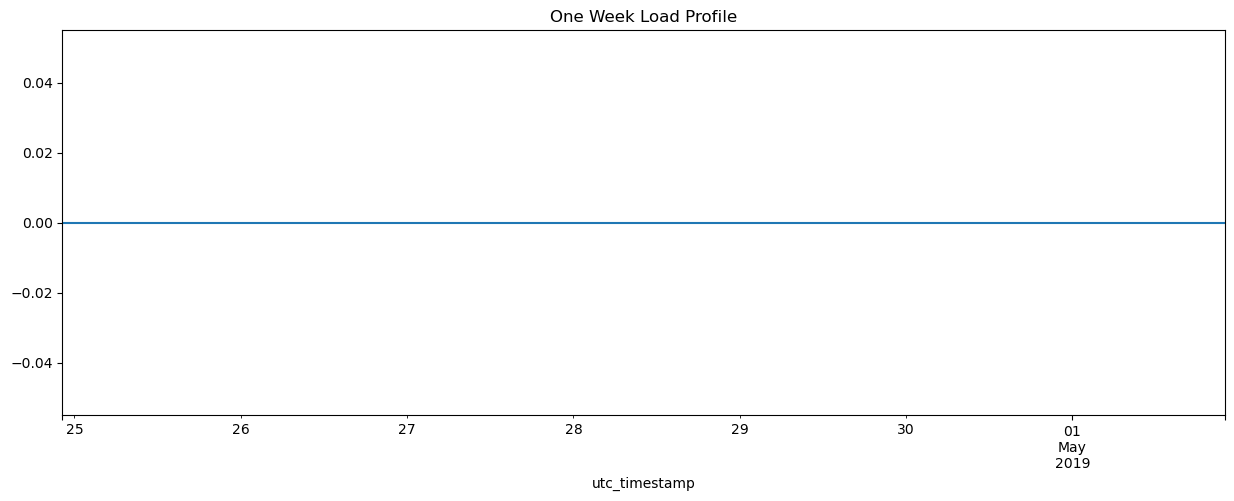

In [46]:
sample = df.iloc[-96*7:]

sample["load"].plot(
    figsize=(15,5)
)

plt.title(
    "One Week Load Profile"
)

plt.show()

In [52]:
naive_pred = (
    y_test.shift(96)
)

mask = naive_pred.notna()

mae = mean_absolute_error(
    y_test[mask],
    naive_pred[mask],
)

rmse = np.sqrt(
    mean_squared_error(
        y_test[mask],
        naive_pred[mask],
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 0.0
RMSE: 0.0


In [53]:
FORECAST_HORIZON = 12

### Building Training Pipeline

In [54]:
from openstef.pipeline.train_model import PredictionJobDataClass

print(PredictionJobDataClass.model_fields.keys())

dict_keys(['id', 'model', 'model_kwargs', 'forecast_type', 'horizon_minutes', 'resolution_minutes', 'lat', 'lon', 'name', 'electricity_bidding_zone', 'train_components', 'description', 'quantiles', 'train_split_func', 'backtest_split_func', 'train_horizons_minutes', 'default_modelspecs', 'save_train_forecasts', 'completeness_threshold', 'minimal_table_length', 'flatliner_threshold_minutes', 'detect_non_zero_flatliner', 'predict_non_zero_flatliner', 'data_balancing_ratio', 'rolling_aggregate_features', 'depends_on', 'sid', 'turbine_type', 'n_turbines', 'hub_height', 'pipelines_to_run', 'alternative_forecast_model_pid', 'data_prep_class', 'model_run_id', 'fallback_strategy'])


/home/eduard/anaconda3/envs/energy-ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [55]:
from openstef.pipeline.train_model import (
    PredictionJobDataClass,
)

pj = PredictionJobDataClass(
    id="microgrid_load",
    name="Microgrid Load Forecast",
    model="xgb",
    forecast_type="demand",
)

In [56]:
train_df.head()

,load,hour,dayofweek,month,dayofyear,weekofyear,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,load_lag_1h,load_lag_6h,load_lag_24h,load_lag_48h,load_lag_7d,load_roll_mean_24h,load_roll_std_24h
utc_timestamp,,,,,,,,,,,,,,,,,,
2014-12-18 18:00:00+00:00,0.042,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.021,0.018,0.019,0.018,0.034,0.081948,0.107700
2014-12-18 18:15:00+00:00,0.085,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.016,0.019,0.341,0.300,0.018,0.082187,0.107584
2014-12-18 18:30:00+00:00,0.455,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.019,0.041,0.168,0.251,0.018,0.079521,0.104222
2014-12-18 18:45:00+00:00,0.368,18,3,12,352,51,0,-1.000000,-1.836970e-16,0.433884,-0.900969,0.020,0.033,0.350,0.326,0.018,0.082510,0.110701
2014-12-18 19:00:00+00:00,0.316,19,3,12,352,51,0,-0.965926,2.588190e-01,0.433884,-0.900969,0.042,0.022,0.347,0.246,0.021,0.082698,0.111173


In [57]:
train_df.columns

Index(['load', 'hour', 'dayofweek', 'month', 'dayofyear', 'weekofyear',
       'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'load_lag_1h', 'load_lag_6h', 'load_lag_24h', 'load_lag_48h',
       'load_lag_7d', 'load_roll_mean_24h', 'load_roll_std_24h'],
      dtype='object')

In [58]:
cols = train_df.columns.tolist()

cols.remove("load")

train_df = train_df[
    ["load"] + cols
]

In [59]:
import inspect

from openstef.pipeline.train_model import (
    train_model_pipeline_core,
)

print(
    inspect.getsource(
        train_model_pipeline_core
    )[:8000]
)

def train_model_pipeline_core(
    pj: PredictionJobDataClass,
    model_specs: ModelSpecificationDataClass,
    input_data: pd.DataFrame,
    old_model: OpenstfRegressor = None,
    horizons: list[float] = DEFAULT_TRAIN_HORIZONS_HOURS,
    ignore_existing_models: bool = False,
) -> Tuple[
    OpenstfRegressor,
    Report,
    ModelSpecificationDataClass,
    tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame],
]:
    """Train model core pipeline.

    Trains a new model given a prediction job, input data and compares it to an old model.
    This pipeline has no database or persistent storage dependencies.

    Args:
        pj: Prediction job
        model_specs: Dataclass containing model specifications
        input_data: Input data
        old_model: Old model to compare to. Defaults to None.
        horizons: Horizons to train on in hours, relevant for feature engineering.
        ignore_existing_models: If True, all existing models, including, hyperparameters are ignored and defsault

In [61]:
from openstef.model.regressors import xgb

dir(xgb)

['OpenstfRegressor',
 'Optional',
 'RegressorMixin',
 'XGBOpenstfRegressor',
 'XGBRegressor',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'np']

In [62]:
from openstef.model.regressors import lgbm

dir(lgbm)

['LGBMOpenstfRegressor',
 'LGBMRegressor',
 'OpenstfRegressor',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__']

### Introdce STEF

In [30]:
from openstef.pipeline.train_model import (
    PredictionJobDataClass,
)

pj = PredictionJobDataClass(
    id="microgrid_load",
    name="Microgrid Load Forecast",
    model="xgb",
    forecast_type="demand",
)